In [1]:
CLUSTERING_ALGO = "genie"
FEAT_ENG_ALGO = "ssnn"

In [2]:
!pip install clustering-benchmarks -q

In [3]:
import clustbench
data_url = "https://github.com/gagolews/clustering-data-v1/raw/v1.1.0"

In [4]:
battery_datasets_dict = {
                         'fcps': ['atom', 'chainlink', 'engytime', 'hepta', 'lsun', 'target', 'tetra', 'twodiamonds', 'wingnut'],
                         'uci': ['ecoli', 'glass', 'ionosphere', 'sonar', 'statlog', 'wdbc', 'wine', 'yeast'],
                         }

# TabPFN: install and test

In [5]:
# Install tabpfn from source
# Clone the repository: shallow for speedup
!git clone --depth 1 https://github.com/PriorLabs/tabpfn

# Speeding up installation in this notebook:
# Remove torch dependency as it is already installed on colab (do not run this in your local setup)
!sed -i "/torch/d" tabpfn/pyproject.toml

# Step 3: Install using the correct directory name 'tabpfn'
!uv pip install -e "tabpfn"

# Install TabPFN extensions for additional functionalities
!git clone https://github.com/PriorLabs/tabpfn-extensions

# Speeding up installation in this notebook:
# Remove torch dependency as it is already installed on colab (do not run this in your local setup)
!sed -i "/torch/d" tabpfn-extensions/pyproject.toml

!uv pip install -e tabpfn-extensions[all]

fatal: destination path 'tabpfn' already exists and is not an empty directory.
Using Python 3.12.12 environment at: /usr
Resolved 37 packages in 36ms
Prepared 1 package in 918ms
Uninstalled 1 package in 0.53ms
Installed 1 package in 1ms
 ~ tabpfn==2.2.1 (from file:///content/tabpfn)
fatal: destination path 'tabpfn-extensions' already exists and is not an empty directory.
Using Python 3.12.12 environment at: /usr
Resolved 70 packages in 62ms
Prepared 1 package in 1.02s
Uninstalled 1 package in 0.57ms
Installed 1 package in 1ms
 ~ tabpfn-extensions==0.1.6 (from file:///content/tabpfn-extensions)


In [6]:
try:
    from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import (
        AutoTabPFNClassifier,
    )

    from tabpfn import TabPFNClassifier, TabPFNRegressor
except ImportError:
    raise ImportError(
        "Warning: Could not import TabPFN / TabPFN extensions. Please run installation above and restart the session afterwards (Runtime > Restart Session)."
    )

In [7]:
# Simple import for TabPFN
from tabpfn import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")

TabPFNClassifier imported successfully.


In [8]:
b = clustbench.load_dataset("uci", "wine", url=data_url)
X, y = b.data, b.labels[0]

In [9]:
X

array([[ 5.69672092e-03, -2.90306939e-03,  2.94930956e-04, ...,
         3.82939725e-04,  6.06291125e-03,  1.47413055e+00],
       [ 9.24944092e-04, -2.57809178e-03, -1.04932287e-03, ...,
         4.29324315e-04,  3.65233387e-03,  1.40461910e+00],
       [ 7.38612686e-04,  1.09901964e-04,  1.40627180e-03, ...,
         3.36106133e-04,  2.58768666e-03,  2.03021889e+00],
       ...,
       [ 1.24803899e-03,  9.00712913e-03, -4.93235909e-04, ...,
        -1.70274477e-03, -4.87350135e-03,  4.08293643e-01],
       [ 7.84919795e-04,  1.17546725e-03,  1.62447448e-05, ...,
        -1.65555859e-03, -4.59615925e-03,  4.31463743e-01],
       [ 5.23372871e-03,  8.17297791e-03,  1.73065801e-03, ...,
        -1.61065376e-03, -4.68849094e-03, -8.66077124e-01]])

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Train and evaluate the TabPFN classifier
tabpfn_classifier = TabPFNClassifier(random_state=42)
tabpfn_classifier.fit(X_train, y_train)
y_pred_proba = tabpfn_classifier.predict_proba(X_test)

# Calculate the ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"TabPFN ROC AUC Score: {roc_auc:.4f}")

tabpfn-v2-classifier-finetuned-zk73skhh.(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

TabPFN ROC AUC Score: 1.0000


In [11]:
X_train.shape

(142, 13)

In [12]:
from tabpfn_extensions.embedding import TabPFNEmbedding

embedding_extractor = TabPFNEmbedding(tabpfn_clf=tabpfn_classifier, n_fold=0)
train_embeddings = embedding_extractor.get_embeddings(
    X_train,
    y_train,
    X_test,
    data_source="train",
)
test_embeddings = embedding_extractor.get_embeddings(
    X_train,
    y_train,
    X_test,
    data_source="test",
)

In [13]:
# The embeddings have shape (n_splits, n_samples, n_features), so we use the first split [0].
train_embeddings.shape

#model.fit(train_embeddings[0], y_train)
#y_pred = model.predict(test_embeddings[0])

(8, 142, 192)

## Create embeddings using TabPFN

In [14]:
import numpy as np
from tabpfn import TabPFNClassifier, TabPFNRegressor
from tabpfn_extensions.embedding import TabPFNEmbedding
import pandas as pd

def ssnn_feat_eng(X):

  # To store embeddings for each feature
  embeddings_list = []

  # Get the number of features
  n_samples, n_features = X.shape

  for feature_idx in range(n_features):

      # Prepare input by removing the current feature
      X_in = np.delete(X, feature_idx, axis=1)  # shape: (n_samples, n_features-1)

      # Target is the left-out feature
      y_target = X[:, feature_idx]  # shape: (n_samples,)

      # Define TabPFN
      tabpfn = TabPFNRegressor(random_state=42)
      tabpfn.fit(X_in, y_target)

      embedding_extractor = TabPFNEmbedding(tabpfn_reg=tabpfn, n_fold=0)
      train_embeddings = embedding_extractor.get_embeddings(
          X_in, # Use X_in for training the embedding extractor
          y_target, # Use y_target for training the embedding extractor
          X_in, # Use X_in for generating embeddings
          data_source="train",
      )

      # Append embeddings
      embeddings_list.append(train_embeddings[0])

  # Concatenate all embeddings horizontally
  X_new = np.hstack(embeddings_list)  # shape: (n_samples, n_embeddings * n_features)
  #X_new_df = pd.DataFrame(X_new, columns=[f'feature_{i+1}_emb_{j+1}' for i in range(n_features) for j in range(n_embeddings)])
  return X_new

## Function get_scores

Get the NCA score of a specific dataset using genie mst algorithm

In [15]:
import genieclust
import sklearn.cluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_scores(battery, dataset, apply_scale=False):
  b = clustbench.load_dataset(battery, dataset, url=data_url)

  X_transformed = b.data
  if apply_scale:
    # Scale the data
    #scaler = StandardScaler()
    #X_transformed = scaler.fit_transform(X_transformed)
    X_transformed = clustbench.preprocess_data(X_transformed, random_state=42)

  #m = sklearn.cluster.KMeans(n_clusters=b.n_clusters[0])
  m = sklearn.cluster.SpectralClustering(n_clusters=b.n_clusters[0], affinity='rbf', random_state=42)
  results = clustbench.fit_predict_many(m, X_transformed, b.n_clusters[0])
  scores = clustbench.get_score(b.labels[0], results)

  return scores

## Function get_scores_with_autoencoder

Get the NCA score of a specific dataset applying the autoencoder transformation to the data and then using genie mst algorithm

In [16]:
import genieclust
import sklearn.cluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_scores_with_feat_eng(battery, dataset, apply_scale=False, apply_PCA=False):
  b = clustbench.load_dataset(battery, dataset, url=data_url)

  X_transformed = b.data

  if apply_scale:
    # Scale the data
    #scaler = StandardScaler()
    #X_transformed = scaler.fit_transform(X_transformed)
    X_transformed = clustbench.preprocess_data(X_transformed, random_state=42)

  X_transformed = ssnn_feat_eng(X_transformed)

  if apply_PCA:
    pca = PCA(n_components=50)
    X_transformed = pca.fit_transform(X_transformed)

  #m = sklearn.cluster.KMeans(n_clusters=b.n_clusters[0])
  m = sklearn.cluster.SpectralClustering(n_clusters=b.n_clusters[0], affinity='rbf', random_state=42)
  results = clustbench.fit_predict_many(m, X_transformed, b.n_clusters[0])
  scores = clustbench.get_score(b.labels[0], results)

  return scores

## Execute get_scores on all datasets as baseline

In [17]:
import tqdm
import pandas as pd
columns = ['Battery', 'Dataset', f'{CLUSTERING_ALGO} NCA Score']
df = pd.DataFrame(columns=columns)
scores_lists = {}
for col in columns:
  scores_lists[col] = []

for battery in tqdm.tqdm(battery_datasets_dict.keys(), desc="Processing Datasets"):
  for dataset in battery_datasets_dict[battery]:
    scores_lists['Battery'].append(battery)
    scores_lists['Dataset'].append(dataset)
    scores_lists[f'{CLUSTERING_ALGO} NCA Score'].append(get_scores(battery, dataset))

df_baseline = pd.DataFrame.from_dict(scores_lists)

Processing Datasets:  50%|█████     | 1/2 [00:26<00:26, 26.67s/it]/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 2000 with accuracies 
[4.16412153e-15 5.45549206e-06 6.06696763e-05]
not reaching the requested tolerance 3.0994415283203125e-06.
Use iteration 1735 instead with accuracy 
3.389275304174492e-06.

  _, diffusion_map = lobpcg(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[1.56923462e-15 1.21812800e-06 8.94969738e-06]
not reaching the requested tolerance 3.0994415283203125e-06.
  _, diffusion_map = lobpcg(
Processing Datasets: 100%|██████████| 2/2 [00:47<00:00, 23.55s/it]


In [18]:
df_baseline.style.apply(lambda row:['']*len(row), axis=1)

,Battery,Dataset,genie NCA Score
0,fcps,atom,1.000000
1,fcps,chainlink,0.502000
2,fcps,engytime,0.919922
3,fcps,hepta,1.000000
4,fcps,lsun,0.837500
5,fcps,target,0.882094
6,fcps,tetra,1.000000
7,fcps,twodiamonds,1.000000
8,fcps,wingnut,0.866142
9,uci,ecoli,0.383545


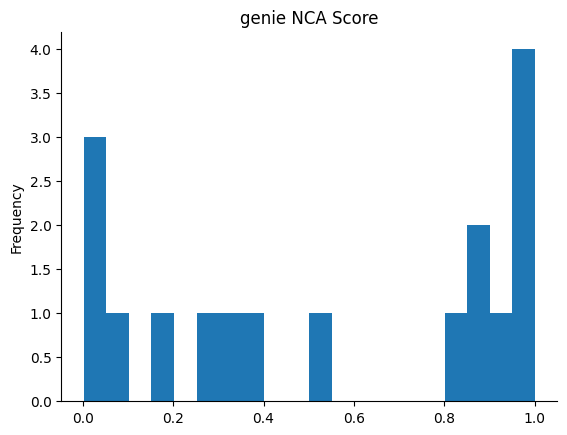

In [19]:
from matplotlib import pyplot as plt
df_baseline[f'{CLUSTERING_ALGO} NCA Score'].plot(kind='hist', bins=20, title=f'{CLUSTERING_ALGO} NCA Score')
plt.gca().spines[['top', 'right',]].set_visible(False)

## Execute get_scores_with_autoencoder on all datasets trying different numbers of embeddings (last hidden layer of the neural network)



In [20]:
scores_lists = {}
for battery in tqdm.tqdm(battery_datasets_dict.keys(), desc="Processing Datasets"):
  for dataset in battery_datasets_dict[battery]:
    column_name = f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} NCA Score'
    if column_name not in scores_lists:
      scores_lists[column_name] = []
    scores_lists[column_name].append(get_scores_with_feat_eng(battery, dataset, apply_scale=False, apply_PCA=True))

df_ssnn = pd.DataFrame.from_dict(scores_lists)

Processing Datasets:   0%|          | 0/2 [00:00<?, ?it/s]

tabpfn-v2-regressor.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

Processing Datasets:  50%|█████     | 1/2 [01:14<01:14, 74.80s/it]/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 1478 with accuracies 
[2.33037137e-14 8.28893091e-07 3.23666439e-06 3.18697099e-06
 4.71817829e-06 2.80202157e-06 2.90968623e-06 2.78809509e-05
 4.87942056e-06]
not reaching the requested tolerance 5.0067901611328125e-06.
Use iteration 1419 instead with accuracy 
5.124870432662414e-06.

  _, diffusion_map = lobpcg(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[5.59399016e-15 8.51381640e-07 3.67157107e-06 3.24311785e-06
 5.53801730e-06 2.80618733e-06 3.48241445e-06 2.13791426e-05
 5.15086357e-06]
not reaching the requested tolerance 5.0067901611328125e-06.
  _, diffusion_map = lobpcg(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (3) found smaller than 

In [21]:
df = pd.concat([df_baseline, df_ssnn], axis=1)

# Final Results

In [22]:
def highlight_scores(row):
    color = 'yellow'
    if row[f'{CLUSTERING_ALGO} NCA Score'] < 0.8 and \
     (row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} NCA Score'] > row[f'{CLUSTERING_ALGO} NCA Score']):
        return [f'background-color: {color}'] * len(row)
    return [''] * len(row)

df.style.apply(highlight_scores, axis=1)

,Battery,Dataset,genie NCA Score,genie+ssnn NCA Score
0,fcps,atom,1.000000,0.007500
1,fcps,chainlink,0.502000,1.000000
2,fcps,engytime,0.919922,0.924316
3,fcps,hepta,1.000000,0.822222
4,fcps,lsun,0.837500,0.770000
5,fcps,target,0.882094,0.730579
6,fcps,tetra,1.000000,0.680000
7,fcps,twodiamonds,1.000000,0.017500
8,fcps,wingnut,0.866142,0.574803
9,uci,ecoli,0.383545,0.073284
